In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as tic
from matplotlib.gridspec import GridSpec

In [2]:
df = pd.read_csv('/kaggle/input/competitions/siim-isic-melanoma-classification/train.csv')
df.head(5)

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [4]:
def save_plots(dir_name, fig, name):
    path = Path(dir_name) / f"{name}.png"
    fig.savefig(path)
    plt.close(fig)
    print(f"Save TO: {path}")

## 💠 **Basic DataFrame Overview**

In [5]:
print(f"Shape Of DataFrame:{df.shape}" 
       f"\n\nColumn Names:{list(df.columns)}"
        f"\n\nData Types Of DataFrame Columns:\n{df.dtypes}" 
         f"\n\nStatistics Summary:\n{df.describe(include='all').to_string()}")

Shape Of DataFrame:(33126, 8)

Column Names:['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']

Data Types Of DataFrame Columns:
image_name                        object
patient_id                        object
sex                               object
age_approx                       float64
anatom_site_general_challenge     object
diagnosis                         object
benign_malignant                  object
target                             int64
dtype: object

Statistics Summary:
          image_name  patient_id    sex    age_approx anatom_site_general_challenge diagnosis benign_malignant        target
count          33126       33126  33061  33058.000000                         32599     33126            33126  33126.000000
unique         33126        2056      2           NaN                             6         9                2           NaN
top     ISIC_9999806  IP_7279968   male           NaN     

## 💠 **Missing Value Analysis**

In [63]:
df.isnull().sum()

image_name                         0
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64

In [84]:
def miss_values_barplot(df, figsize, dir_name, name, percentage=False):
    fig=plt.figure(figsize=figsize)
    if percentage:
        miss_plot=((df.isnull().sum())/len(df)*100).round(2).sort_values(ascending=True)
        color=["#D85A30" if v > 0 else "#B4B2A9" for v in miss_plot.values]
        sns.barplot(x=miss_plot.values, y=miss_plot.index, hue=miss_plot.index, palette=color, orient="h", legend=False)
        for i, v in enumerate(miss_plot.values):
            if v>0:
                plt.text(v+0.02, i, f"{v}%", va="center", fontsize=10)
        x_max=miss_plot.values.max()
        plt.xlim(0, x_max*1.15) 
        plt.title("Missing Values Per Column In (%)", fontweight="bold")
        plt.xlabel("Missing Percentage (%)")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
        save_plots(dir_name, fig, name) 
    else:
        miss_plot=df.isnull().sum().sort_values(ascending=True)
        color=["#D85A30" if v > 0 else "#B4B2A9" for v in miss_plot.values]
        sns.barplot(x=miss_plot.values, y=miss_plot.index, hue=miss_plot.index, palette=color, orient="h",legend=False)
        for i, v in enumerate(miss_plot.values):
            if v>0:
                plt.text(v+3, i, str(v), va="center", fontsize=10)
        x_max=miss_plot.values.max()
        plt.xlim(0, x_max*1.15) 
        plt.title("Missing Values Per Column", fontweight="bold")
        plt.xlabel("Missing Count")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
        save_plots(dir_name, fig, name)

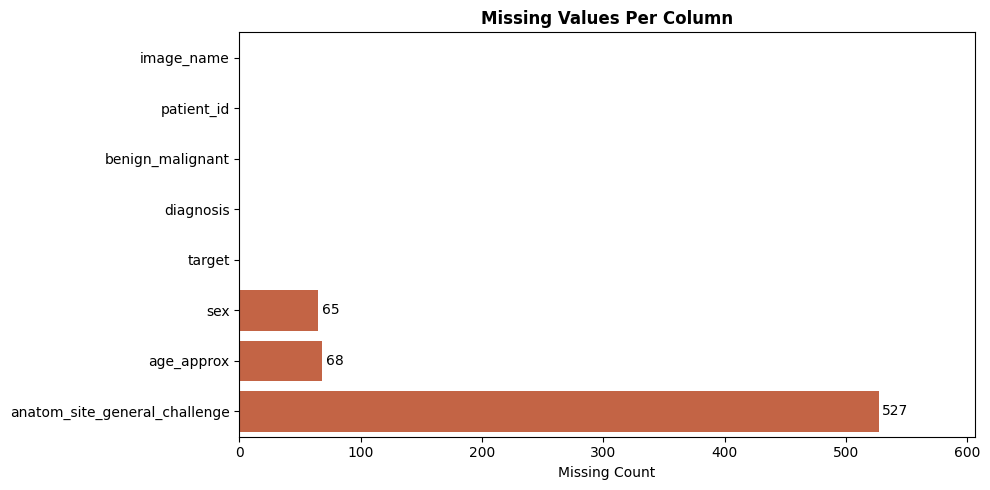

Save TO: /kaggle/working/missing_vale_count.png


In [85]:
miss_values_barplot(df=df, figsize=(10,5), dir_name="/kaggle/working/", name="missing_vale_count", percentage=False)

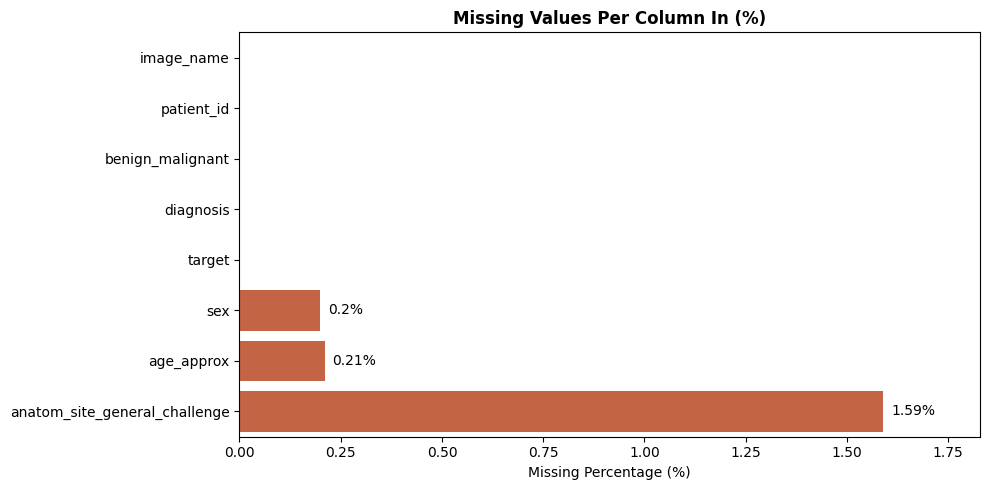

Save TO: /kaggle/working/missing_vale_per.png


In [87]:
miss_values_barplot(df=df, figsize=(10,5), dir_name="/kaggle/working/", name="missing_vale_per", percentage=True)

In [69]:
def missing_vale_heatmap(df, sample_num, figsize, dir_name, name):
    miss_mask=df.sample(min(sample_num, len(df)), random_state=42).isnull()
    fig=plt.figure(figsize=figsize)
    sns.heatmap(miss_mask.T, cbar=True, yticklabels=True, xticklabels=False, cmap=["#E6F1FB", "#D85A30"])
    plt.title("Missing Value Map (N row sample, Orange = Missing)", fontweight="bold")
    plt.xlabel("Sample Rows")
    plt.show()
    save_plots(dir_name, fig, name)

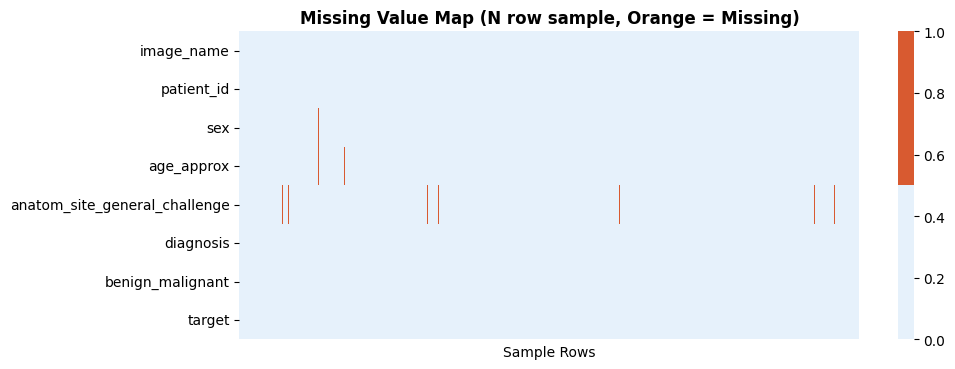

Save TO: /kaggle/working/missing_values_heatmap.png


In [70]:
missing_vale_heatmap(df=df, sample_num=10000, figsize=(10,4), dir_name="/kaggle/working/", name="missing_values_heatmap")

## 💠 **Univariate Analysis**

In [150]:
def dis_plot_for_clm(figsize, df, col, dir_name, name, dis_per=False):
    fig = plt.figure(figsize=figsize)
    if dis_per:
        count_per = df[col].value_counts(normalize=True) * 100
        b=sns.barplot(x=count_per.index, y=count_per.values, hue=count_per.index, palette='viridis')
        for y in b.patches:
          b.annotate(f'{y.get_height():.2f}%', (y.get_x() + y.get_width() / 2., y.get_height()), 
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
        y_max=max([p.get_height() for p in b.patches])
        plt.ylim(0, y_max*1.15) 
        plt.title(f'{col} Distribution In (%)')
        plt.xlabel(f'{col}')
        plt.ylabel(f'{col} Percentage (%)')
        plt.xticks(rotation=30)
        plt.show()
        save_plots(dir_name, fig, name)
    else:
        counts = df[col].value_counts(dropna=False)
        a=sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=True)
        for x in a.patches:
          a.annotate(f'{int(x.get_height())}', (x.get_x() + x.get_width() / 2., x.get_height()),
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
        y_max=max([p.get_height() for p in a.patches])
        plt.ylim(0, y_max*1.15) 
        plt.title(f'{col} Distribution')
        plt.xlabel(f'{col}')
        plt.ylabel(f'{col} Counts')
        plt.xticks(rotation=30)
        plt.show()
        save_plots(dir_name, fig, name)

### 💠 **Check The Class Distribution**

In [151]:
print(f"{df.benign_malignant.unique()}" 
       f"\n\n{df.target.value_counts()}")

['benign' 'malignant']

target
0    32542
1      584
Name: count, dtype: int64


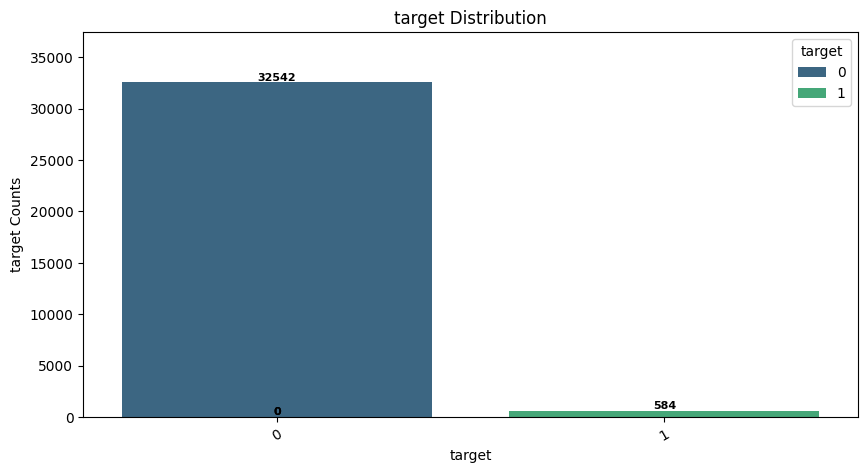

Save TO: /kaggle/working/target_class_count.png


In [152]:
dis_plot_for_clm(figsize=(10,5), df=df, col="target", dir_name="/kaggle/working/", name="target_class_count", dis_per=False)

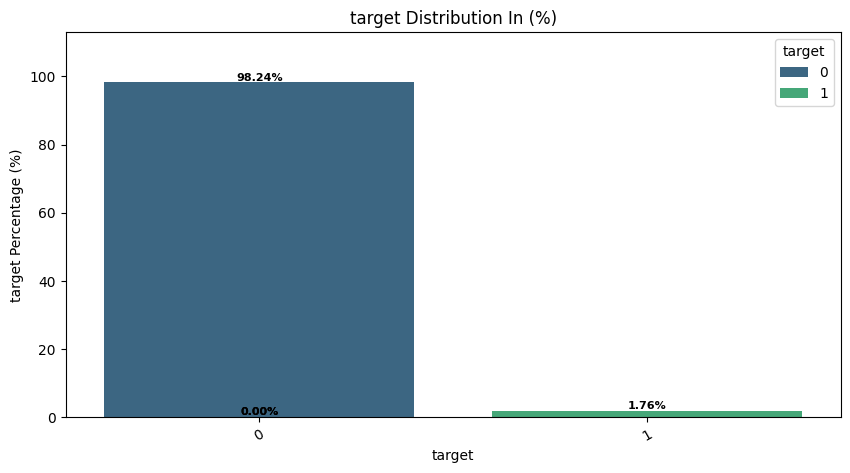

Save TO: /kaggle/working/target_class_count_per.png


In [153]:
dis_plot_for_clm(figsize=(10,5), df=df, col="target", dir_name="/kaggle/working/", name="target_class_count_per", dis_per=True)

In [168]:
print(f"Imbalance Ratio:{(df.target.value_counts()[0])/(df.target.value_counts()[1]):.1f}:1")

Imbalance Ratio:55.7:1


### 💠 **Check Other Column Distribution**

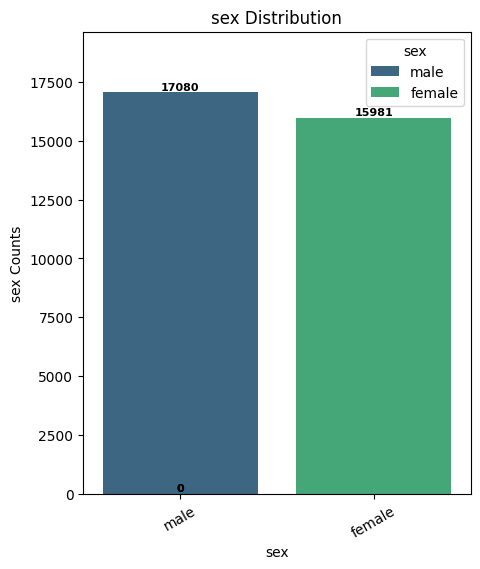

Save TO: /kaggle/working/sex_dis.png


In [157]:
dis_plot_for_clm(figsize=(5,6), df=df, col='sex', dir_name="/kaggle/working/", name="sex_dis", dis_per=False)

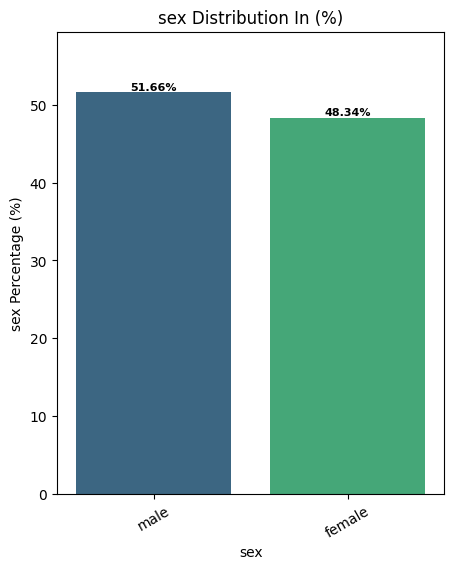

Save TO: /kaggle/working/sex_dis_per.png


In [169]:
dis_plot_for_clm(figsize=(5,6), df=df, col='sex', dir_name="/kaggle/working/", name="sex_dis_per", dis_per=True)

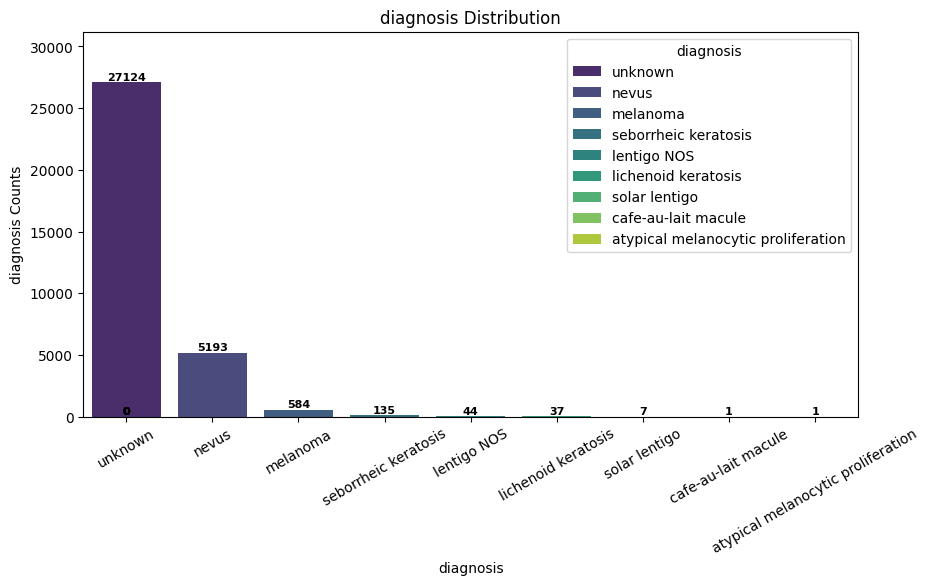

Save TO: /kaggle/working/diagnosis_dis.png


In [159]:
dis_plot_for_clm(figsize=(10,5),df=df, col='diagnosis', dir_name="/kaggle/working/", name="diagnosis_dis", dis_per=False)

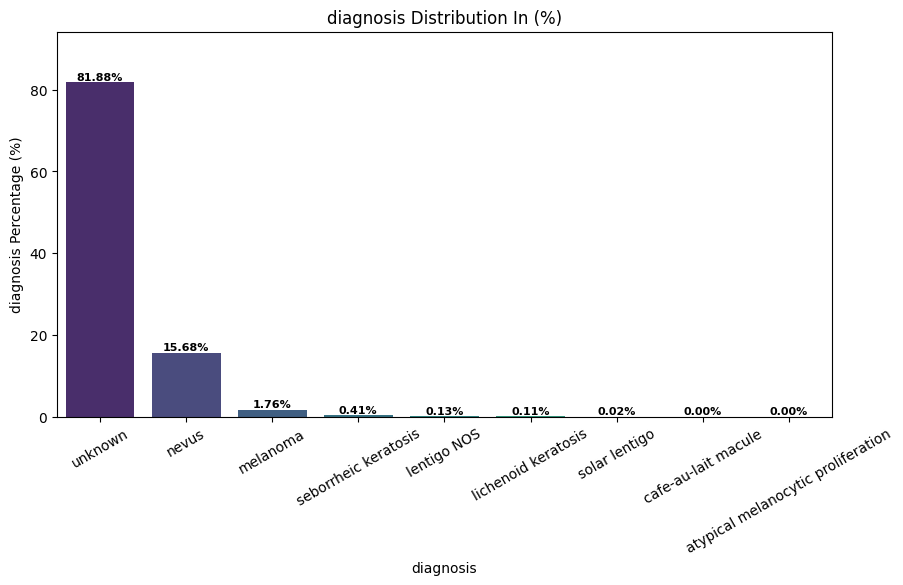

Save TO: /kaggle/working/diagnosis_dis_per.png


In [170]:
dis_plot_for_clm(figsize=(10,5),df=df, col='diagnosis', dir_name="/kaggle/working/", name="diagnosis_dis_per", dis_per=True)

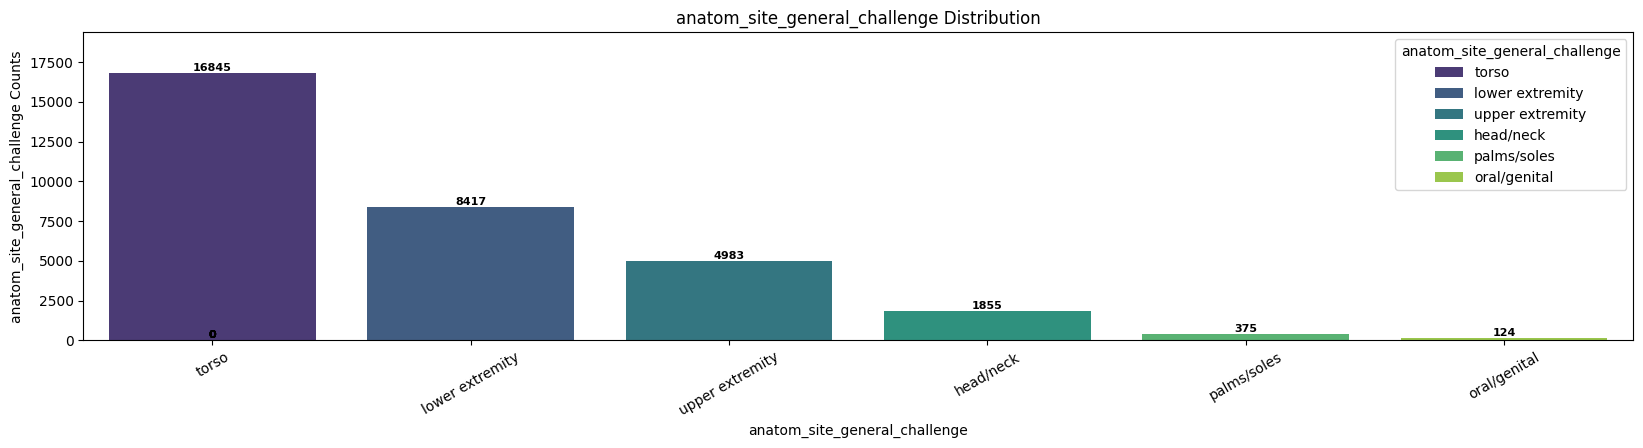

Save TO: /kaggle/working/anatom_site_general_challenge_dis.png


In [171]:
dis_plot_for_clm(figsize=(20,4), df=df, col="anatom_site_general_challenge", dir_name="/kaggle/working/", name="anatom_site_general_challenge_dis", dis_per=False)

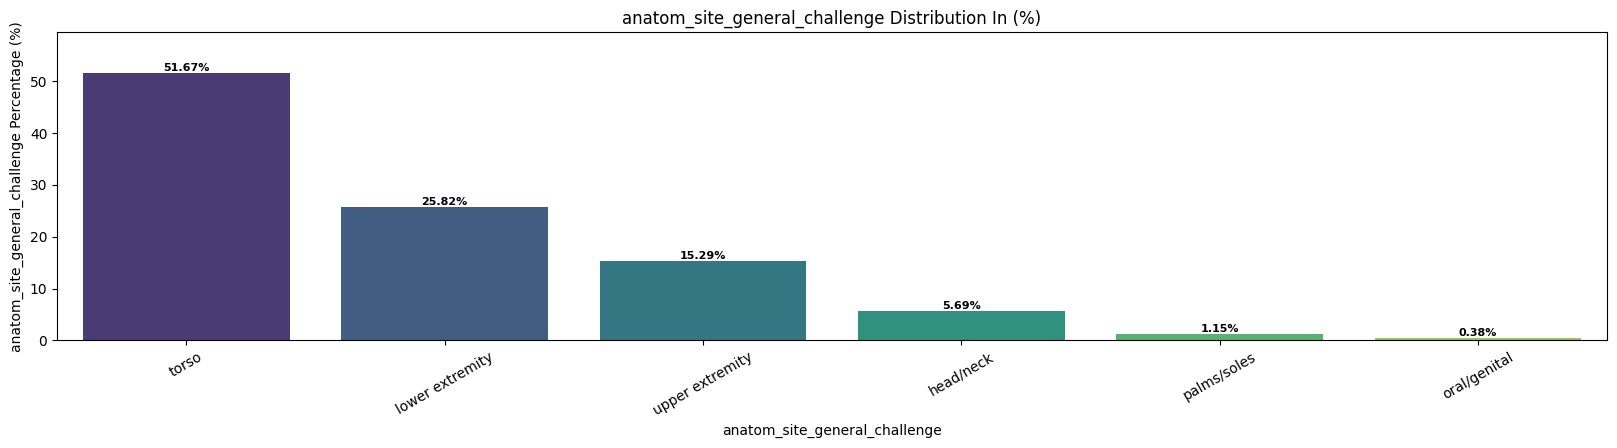

Save TO: /kaggle/working/anatom_site_general_challenge_dis_per.png


In [172]:
dis_plot_for_clm(figsize=(20,4), df=df, col="anatom_site_general_challenge", dir_name="/kaggle/working/", name="anatom_site_general_challenge_dis_per", dis_per=True)

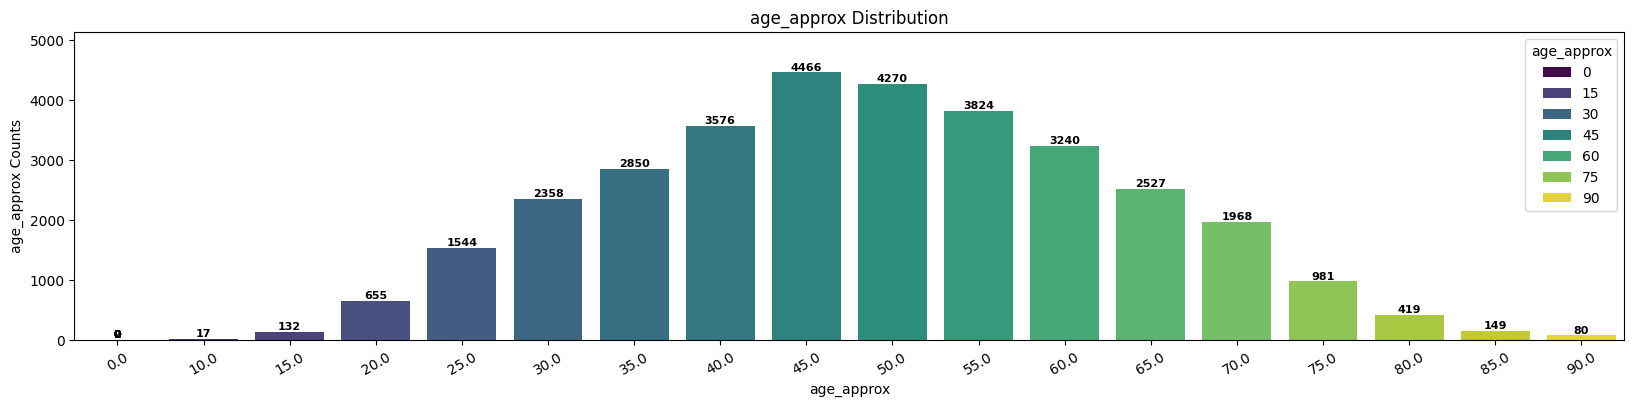

Save TO: /kaggle/working/age_approx_dis.png


In [173]:
dis_plot_for_clm(figsize=(20,4), df=df, col="age_approx", dir_name="/kaggle/working/", name="age_approx_dis", dis_per=False)

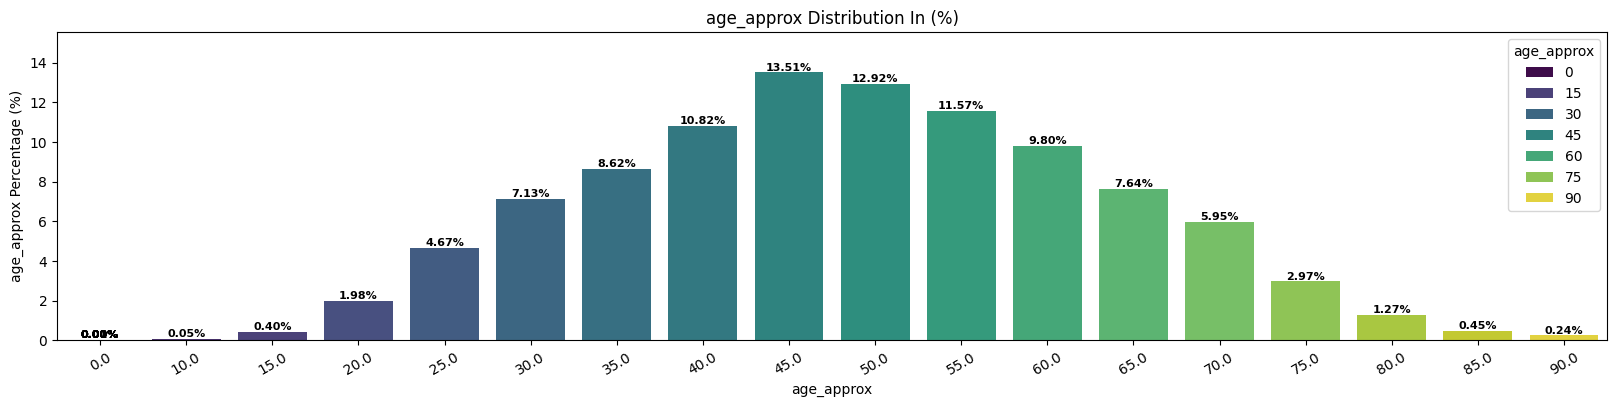

Save TO: /kaggle/working/age_approx_dis_per.png


In [174]:
dis_plot_for_clm(figsize=(20,4), df=df, col="age_approx", dir_name="/kaggle/working/", name="age_approx_dis_per", dis_per=True)

## 💠 **Bivariate Analysis**

In [248]:
print("\n" + "=" * 60)
print("6. BIVARIATE CROSS-TABS (vs target)")
print("=" * 60)
 
for col in ["sex", "anatom_site_general_challenge", "diagnosis"]:
   print(f"\n--- {col} × target ---")
   ct = pd.crosstab(df[col], df["target"], margins=True)
   ct.columns.name = None
   ct.index.name = col
   ct.columns = ["Benign (0)", "Malignant (1)", "All"]
   print(ct)


6. BIVARIATE CROSS-TABS (vs target)

--- sex × target ---
        Benign (0)  Malignant (1)    All
sex                                     
female       15761            220  15981
male         16716            364  17080
All          32477            584  33061

--- anatom_site_general_challenge × target ---
                               Benign (0)  Malignant (1)    All
anatom_site_general_challenge                                  
head/neck                            1781             74   1855
lower extremity                      8293            124   8417
oral/genital                          120              4    124
palms/soles                           370              5    375
torso                               16588            257  16845
upper extremity                      4872            111   4983
All                                 32024            575  32599

--- diagnosis × target ---
                                    Benign (0)  Malignant (1)    All
diagnosis      

### 💠 **Age Distribution [Benign vs Malignant]**

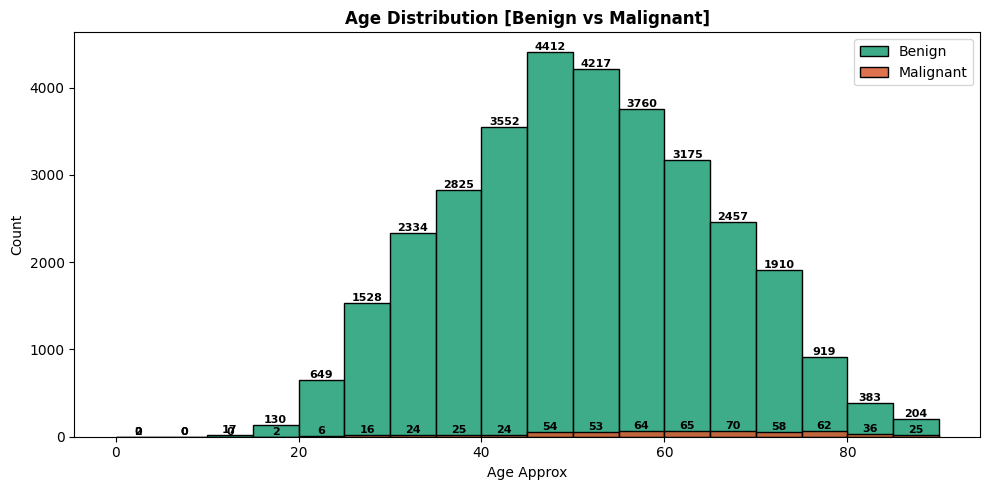

Save TO: /kaggle/working/age_distribution_benign_vs_malignant.png


In [226]:
fig, axs=plt.subplots(figsize=(10,5))
sns.histplot(data=df[df["target"]==0],x="age_approx", binrange=(0,90), binwidth=5, alpha=0.85, color="#1D9E75", label="Benign",ax=axs)
sns.histplot(data=df[df["target"]==1],x="age_approx", binrange=(0,90), binwidth=5, alpha=0.85, color="#D85A30", label="Malignant",ax=axs)
for bar in axs.patches:
    axs.annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.title("Age Distribution [Benign vs Malignant]", fontweight="bold")
plt.xlabel("Age Approx")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
save_plots(dir_name="/kaggle/working/", fig=fig, name="age_distribution_benign_vs_malignant")

### 💠 **Age by Target KDE Plot**

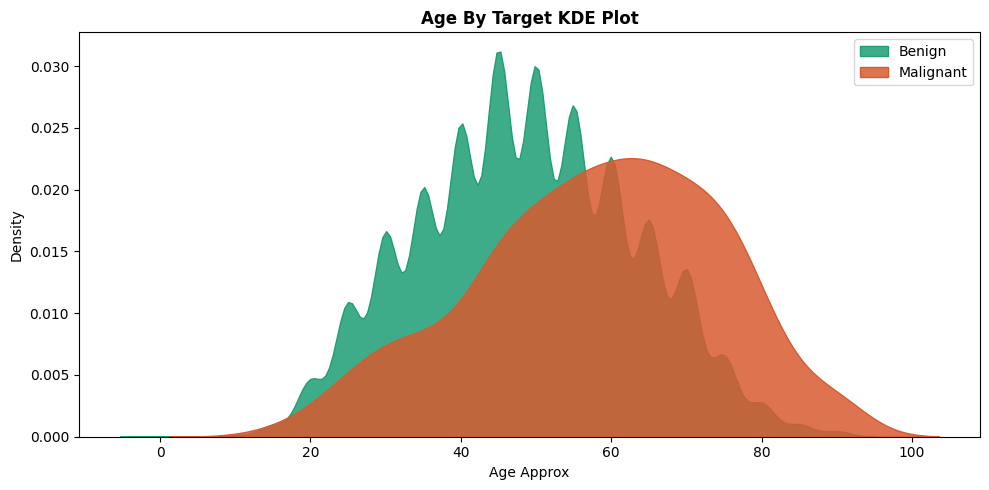

Save TO: /kaggle/working/Age_by_target_KDE.png


In [244]:
fig, axs=plt.subplots(figsize=(10,5))
sns.kdeplot(df.loc[df["target"]==0, "age_approx"].dropna(), fill=True, alpha=0.85, color="#1D9E75", label="Benign",ax=axs)
sns.kdeplot(df.loc[df["target"]==1, "age_approx"].dropna(), fill=True, alpha=0.85, color="#D85A30", label="Malignant",ax=axs)
plt.title("Age By Target KDE Plot", fontweight="bold")
plt.xlabel("Age Approx")
plt.legend()
plt.tight_layout()
plt.show()
save_plots(dir_name="/kaggle/working/", fig=fig, name="Age_by_target_KDE")

## 💠 **Multivariant Analysis**

### 💠 **Correlation Heatmap**

In [202]:
df_2=df.copy()
df_2["sex_encoded"]=df["sex"].map({"male":1, "female":0})
df_2["anatom_site_encoded"]=df.anatom_site_general_challenge.astype("category").cat.codes
df_2["diagnosis_encoded"]=df.diagnosis.astype("category").cat.codes
cols=["sex_encoded","anatom_site_encoded", "diagnosis_encoded", "age_approx", "target"]
corr=df_2[cols].corr()

In [209]:
def corr_heatmap(figsize, corr, dir_name, name):
    fig=plt.figure(figsize=figsize)
    sns.heatmap(corr.round(3), annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5,square=True, annot_kws={"fontsize":9})
    plt.title("Correlation Heatmap", fontweight="bold", fontsize="20")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=30)
    plt.tight_layout()
    plt.show()
    save_plots(dir_name, fig, name)

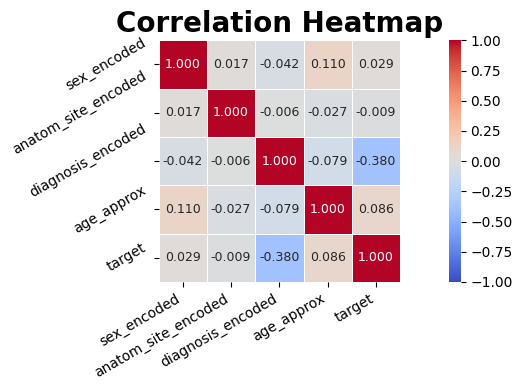

Save TO: /kaggle/working/correlation_heatmap.png


In [210]:
corr_heatmap(figsize=(10,4), corr=corr, dir_name="/kaggle/working/", name="correlation_heatmap")

### 💠 **Pairplot**

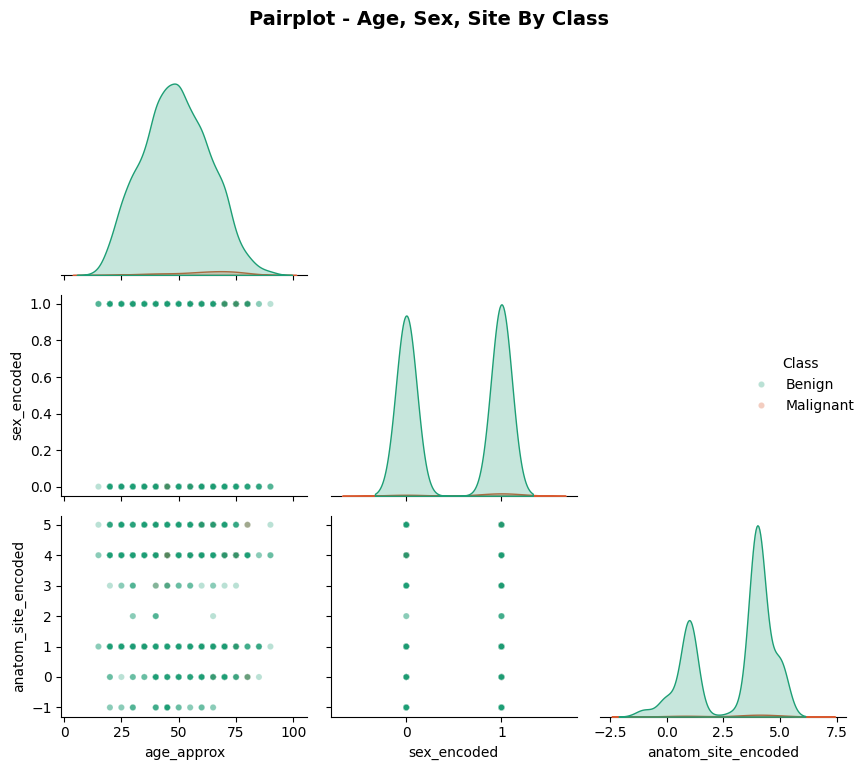

Save TO: /kaggle/working/pairplot.png


In [233]:
df_pair=df_2[["age_approx", "sex_encoded", "anatom_site_encoded", "target"]].dropna()
df_pair["Class"]=df_pair["target"].map({0:"Benign", 1:"Malignant"})
plot=sns.pairplot(df_pair.sample(min(2000, len(df_pair)), random_state=42),
                  vars=["age_approx", "sex_encoded", "anatom_site_encoded"],
                  hue="Class", palette={"Benign": "#1D9E75", "Malignant": "#D85A30"},
                  plot_kws={"alpha": 0.30, "s": 20}, diag_kind="kde", corner=True)
plot.figure.suptitle("Pairplot - Age, Sex, Site By Class", y=1.02, fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()
save_plots(dir_name="/kaggle/working/", fig=fig, name="pairplot")